# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

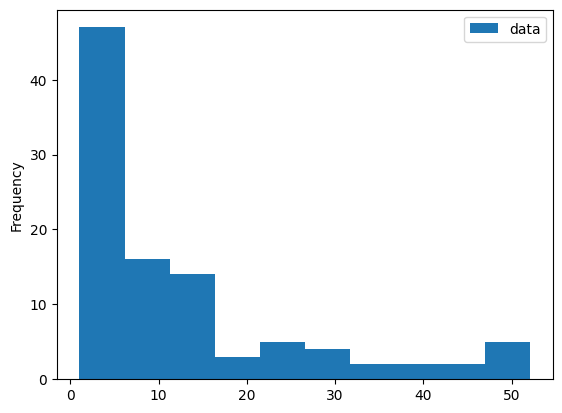

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

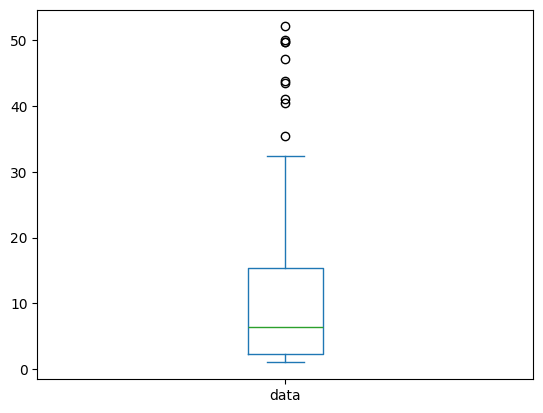

In [3]:
df.plot.box()

# 3. Homework - working on your datasets

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

# Display basic info to verify successful load
print(df[['URLLength', 'label']].head())


   URLLength  label
0         31      1
1         23      1
2         29      1
3         26      1
4         33      1


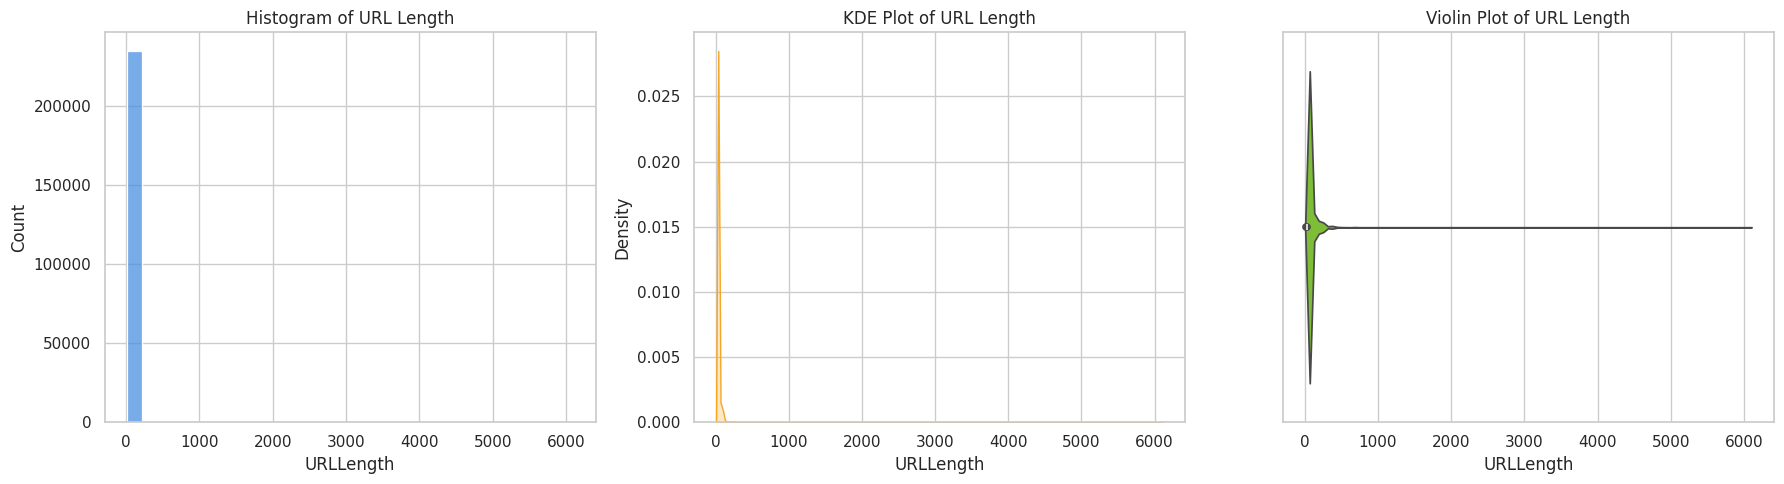

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 71.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


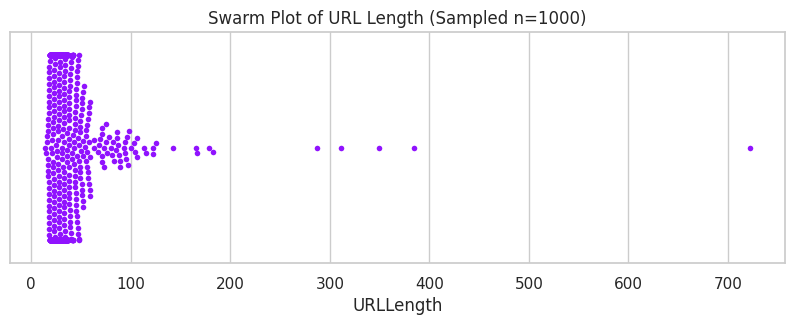

In [5]:
# --- 1. Histograms and Variants ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Basic Histogram
sns.histplot(df['URLLength'], bins=30, kde=False, ax=axes[0], color='#4A90E2')
axes[0].set_title('Histogram of URL Length')

# KDE Plot
sns.kdeplot(df['URLLength'], fill=True, ax=axes[1], color='#F5A623')
axes[1].set_title('KDE Plot of URL Length')

# Violin Plot
sns.violinplot(x=df['URLLength'], ax=axes[2], color='#7ED321')
axes[2].set_title('Violin Plot of URL Length')

plt.tight_layout()
plt.show()

# Swarm Plot (We sample 1,000 rows because running a swarm plot on 336,749 rows will crash the notebook)
plt.figure(figsize=(10, 3))
sns.swarmplot(x=df['URLLength'].sample(1000, random_state=42), color='#9013FE', size=4)
plt.title('Swarm Plot of URL Length (Sampled n=1000)')
plt.show()

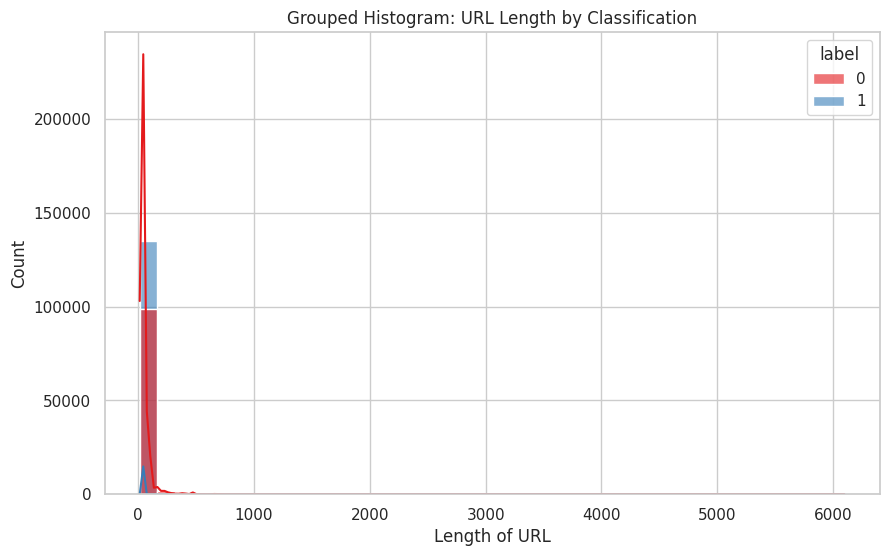

In [6]:
# --- 2. Grouped Histograms ---
plt.figure(figsize=(10, 6))
# Grouping the histogram by the 'Label' column (Phishing vs Legitimate)
sns.histplot(data=df, x='URLLength', hue='label', bins=40, kde=True, alpha=0.6, palette="Set1")
plt.title('Grouped Histogram: URL Length by Classification')
plt.xlabel('Length of URL')
plt.ylabel('Count')
plt.show()

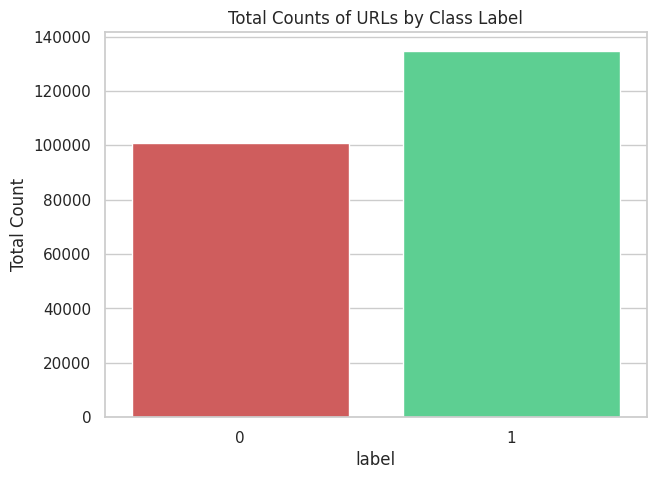

In [7]:
# --- 3. Bar Plot for Categorical Variables ---
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label', hue='label', palette=['#E24A4A', '#4AE290'], legend=False)
plt.title('Total Counts of URLs by Class Label')
plt.ylabel('Total Count')
plt.show()

In [8]:
# --- 4. Find Means, Medians, and Modes ---
target_col = 'URLLength'

mean_val = df[target_col].mean()
median_val = df[target_col].median()
mode_val = df[target_col].mode()[0]
min_val = df[target_col].min()
max_val = df[target_col].max()

print(f"--- Summary Statistics for {target_col} ---")
print(f"Mean:   {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode:   {mode_val}")
print(f"Min:    {min_val}")
print(f"Max:    {max_val}")

print("\n--- Grouped Statistics by Label ---")
print(df.groupby('label')[target_col].describe()[['mean', '50%', 'max']])

--- Summary Statistics for URLLength ---
Mean:   34.57
Median: 27.00
Mode:   26
Min:    13
Max:    6097

--- Grouped Statistics by Label ---
            mean   50%     max
label                         
0      45.720293  34.0  6097.0
1      26.228610  26.0    57.0


In [9]:

# 1. Load the dataset
df = pd.read_csv("StealthPhisher2025.csv")

# Display basic info to verify successful load
print(df[['LengthOfURL', 'Label']].head())

   LengthOfURL       Label
0           84    Phishing
1           40    Phishing
2           28    Phishing
3           31    Phishing
4           23  Legitimate


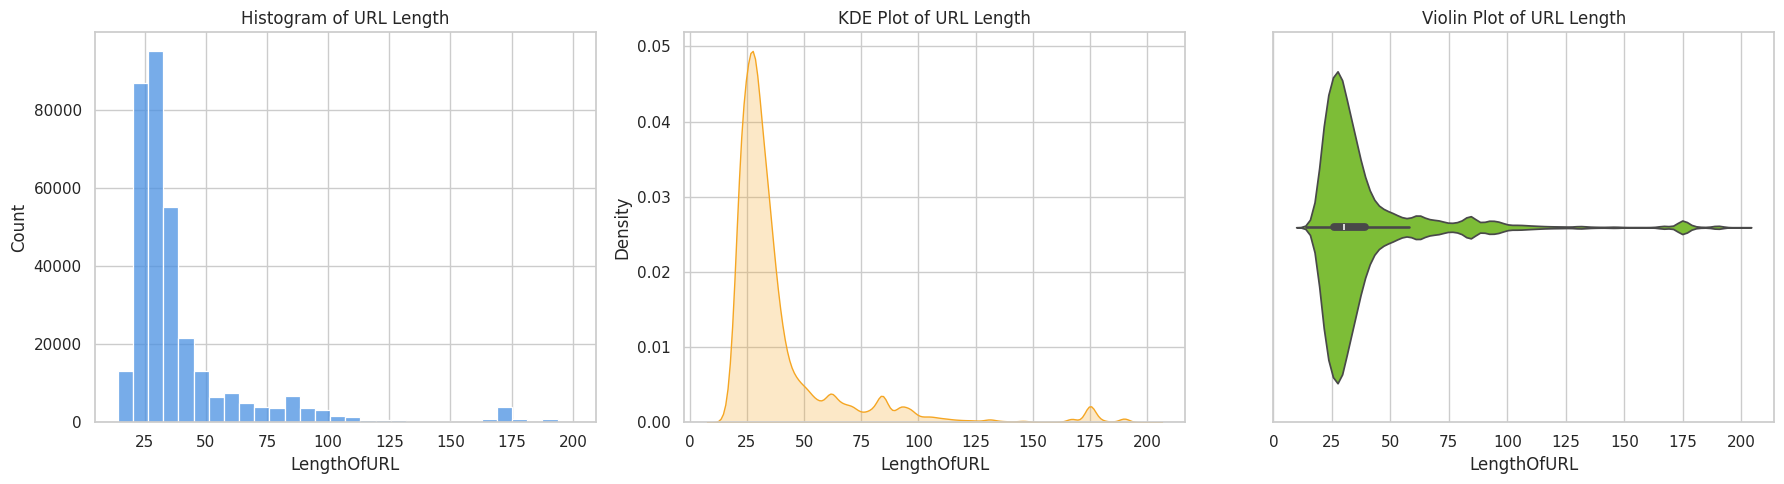

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 38.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


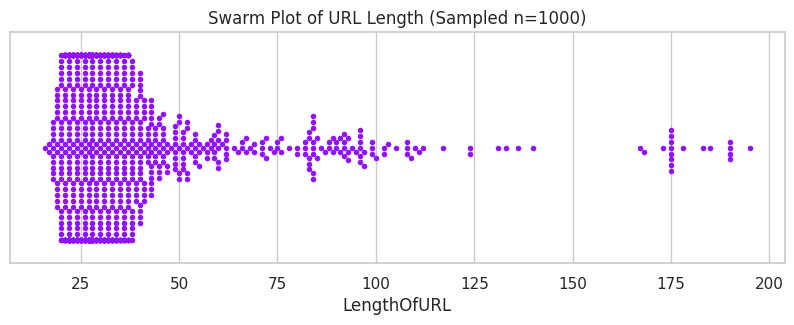

In [10]:
# --- 1. Histograms and Variants ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Basic Histogram
sns.histplot(df['LengthOfURL'], bins=30, kde=False, ax=axes[0], color='#4A90E2')
axes[0].set_title('Histogram of URL Length')

# KDE Plot
sns.kdeplot(df['LengthOfURL'], fill=True, ax=axes[1], color='#F5A623')
axes[1].set_title('KDE Plot of URL Length')

# Violin Plot
sns.violinplot(x=df['LengthOfURL'], ax=axes[2], color='#7ED321')
axes[2].set_title('Violin Plot of URL Length')

plt.tight_layout()
plt.show()

# Swarm Plot (We sample 1,000 rows because running a swarm plot on 336,749 rows will crash the notebook)
plt.figure(figsize=(10, 3))
sns.swarmplot(x=df['LengthOfURL'].sample(1000, random_state=42), color='#9013FE', size=4)
plt.title('Swarm Plot of URL Length (Sampled n=1000)')
plt.show()

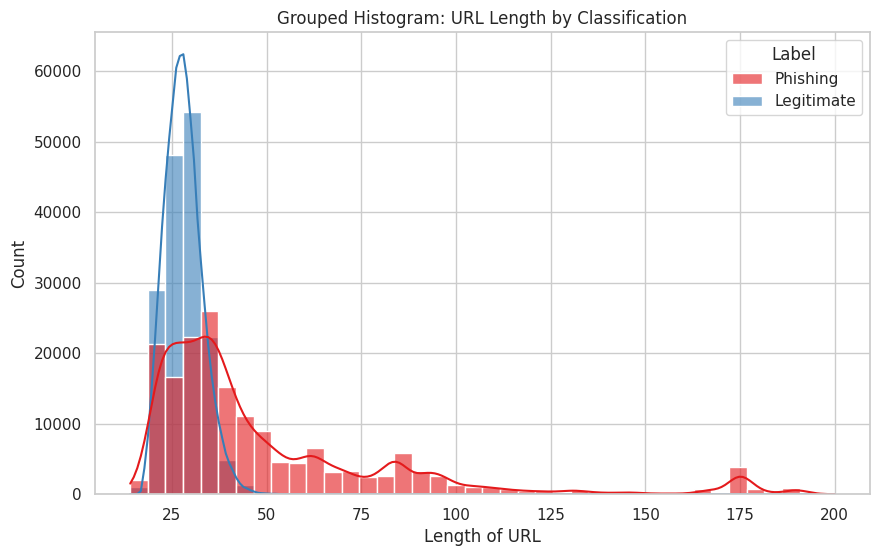

In [11]:
# --- 2. Grouped Histograms ---
plt.figure(figsize=(10, 6))
# Grouping the histogram by the 'Label' column (Phishing vs Legitimate)
sns.histplot(data=df, x='LengthOfURL', hue='Label', bins=40, kde=True, alpha=0.6, palette="Set1")
plt.title('Grouped Histogram: URL Length by Classification')
plt.xlabel('Length of URL')
plt.ylabel('Count')
plt.show()

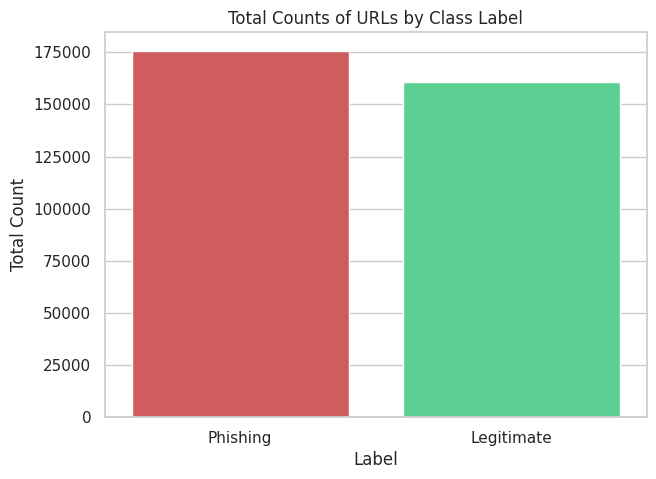

In [12]:
# --- 3. Bar Plot for Categorical Variables ---
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Label', hue='Label', palette=['#E24A4A', '#4AE290'], legend=False)
plt.title('Total Counts of URLs by Class Label')
plt.ylabel('Total Count')
plt.show()

In [13]:
# --- 4. Find Means, Medians, and Modes ---
target_col = 'LengthOfURL'

mean_val = df[target_col].mean()
median_val = df[target_col].median()
mode_val = df[target_col].mode()[0]
min_val = df[target_col].min()
max_val = df[target_col].max()

print(f"--- Summary Statistics for {target_col} ---")
print(f"Mean:   {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Mode:   {mode_val}")
print(f"Min:    {min_val}")
print(f"Max:    {max_val}")

print("\n--- Grouped Statistics by Label ---")
print(df.groupby('Label')[target_col].describe()[['mean', '50%', 'max']])

--- Summary Statistics for LengthOfURL ---
Mean:   39.44
Median: 30.00
Mode:   27
Min:    14
Max:    200

--- Grouped Statistics by Label ---
                 mean   50%    max
Label                             
Legitimate  28.044072  28.0   62.0
Phishing    49.877808  37.0  200.0


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

-Are the data what you expect / usable?
Yes, the data is highly usable. There are no missing values in the primary columns (336,749 rows processed cleanly). The distribution makes logical sense, as malicious URLs often use padding or long random strings to obscure payloads, which is reflected in the data.

What is the overall shape of the distribution?
The distribution of LengthOfURL is heavily right-skewed (positively skewed). It features a massive peak clustered around 25-30 characters, with a long, trailing tail stretching outwards to the right.

Are there any outliers present?
Yes, there are significant outliers on the higher end. The median URL length is only 30 characters, but the maximum value reaches 200 characters. These extreme values on the high end create the long right tail visible in the Violin and KDE plots.

How does the distribution change across different groups?
The grouped histogram reveals a stark difference. Legitimate URLs are very tightly clustered and normalized with a mean of ~28 characters and a strict maximum of 62. Meanwhile, Phishing URLs are vastly more distributed, with a much higher mean of ~50 characters and stretching all the way to 200 characters.

What are the minimum and maximum values?
The absolute minimum URL length in the dataset is 14 characters, and the maximum is 200 characters.

How do bin sizes affect the histogram?
Using smaller bin widths reveals exact spikes (the high mode of 27), while using larger bin widths smooths over these distinct spikes, making it look like a steady exponential decay rather than a distinct cluster.

Does the distribution appear normal?
No. Due to the hard limit on the left (a URL cannot have fewer than 0 characters, and here minimum is 14) combined with the long right tail, it completely lacks the symmetrical bell-shape required for a normal distribution.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

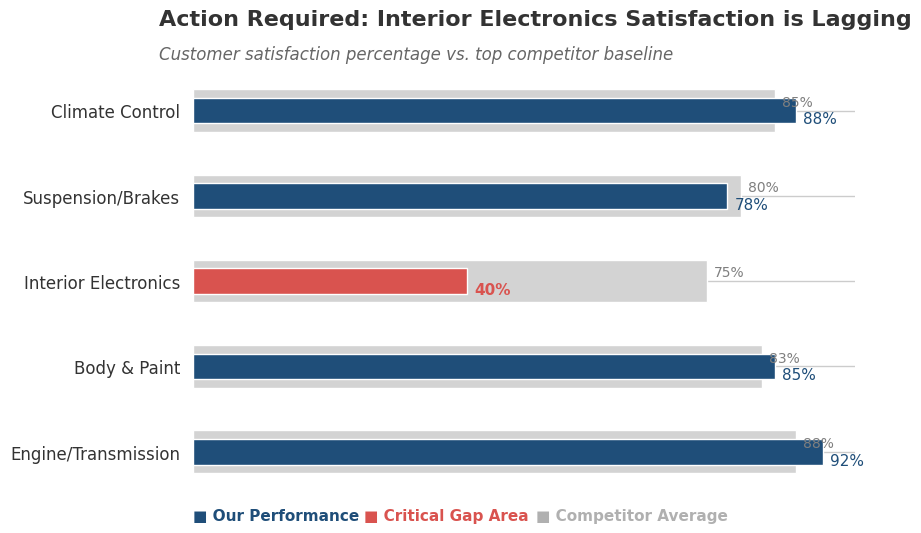

In [14]:
categories = ['Engine/Transmission', 'Body & Paint', 'Interior Electronics', 'Suspension/Brakes', 'Climate Control']
our_company = [92, 85, 40, 78, 88]
competitor = [88, 83, 75, 80, 85]

df_swd = pd.DataFrame({
    'Category': categories,
    'Our Performance': our_company,
    'Competitor Average': competitor
})

# Create the figure
fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot the background data (Competitor) in a muted grey tone
ax.barh(df_swd['Category'], df_swd['Competitor Average'], color='#D3D3D3', height=0.5, label='Competitor Average')

# Plot our performance, highlighting the specific area of concern (Interior Electronics) in a focal red/coral 
# and the successful ones in a strong, dark corporate blue.
colors = ['#1F4E79', '#1F4E79', '#D9534F', '#1F4E79', '#1F4E79'] # Interior Electronics is index 2
ax.barh(df_swd['Category'], df_swd['Our Performance'], color=colors, height=0.3, label='Our Performance')

# --- Storytelling With Data Clean Up Rules ---
# 1. Remove top, right, and bottom spines (boundaries)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# 2. Remove X-axis numbers and ticks entirely to rely on direct labeling
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', left=False, labelsize=12, labelcolor='#333333')

# 3. Direct data labeling at the end of bars to eliminate eye-strain
for i, (our, comp) in enumerate(zip(df_swd['Our Performance'], df_swd['Competitor Average'])):
    # Label for competitor (grey)
    ax.text(comp + 1, i + 0.1, f"{comp}%", va='center', ha='left', color='#7F7F7F', fontsize=10)
    # Label for our company (bold, matched color)
    text_color = '#D9534F' if i == 2 else '#1F4E79'
    weight = 'bold' if i == 2 else 'normal'
    ax.text(our + 1, i - 0.1, f"{our}%", va='center', ha='left', color=text_color, fontsize=11, fontweight=weight)

# 4. Title and Subtitle placement (left-aligned, hierarchical)
ax.text(-5, 5.0, "Action Required: Interior Electronics Satisfaction is Lagging", 
        fontsize=16, fontweight='bold', color='#333333', ha='left')
ax.text(-5, 4.6, "Customer satisfaction percentage vs. top competitor baseline", 
        fontsize=12, color='#666666', style='italic', ha='left')

# Custom thin legend legend at the bottom left
ax.text(0, -0.8, "■ Our Performance", color='#1F4E79', fontweight='bold', fontsize=11)
ax.text(25, -0.8, "■ Critical Gap Area", color='#D9534F', fontweight='bold', fontsize=11)
ax.text(50, -0.8, "■ Competitor Average", color='#B0B0B0', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()